In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Import libraries and load the image.**

In [5]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [6]:
import os

# نتعمق جوا
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    for f in files[:5]:
        print(os.path.join(root, f))
    if files:
        break

/kaggle/input/datasets/hryan007/cxr-lung-dataset-png/c0824.png
/kaggle/input/datasets/hryan007/cxr-lung-dataset-png/c0445.png
/kaggle/input/datasets/hryan007/cxr-lung-dataset-png/c2012.png
/kaggle/input/datasets/hryan007/cxr-lung-dataset-png/n0503.png
/kaggle/input/datasets/hryan007/cxr-lung-dataset-png/c2700.png


✅ عدد الصور: 4882
📁 مثال: /kaggle/input/datasets/hryan007/cxr-lung-dataset-png/c0824.png


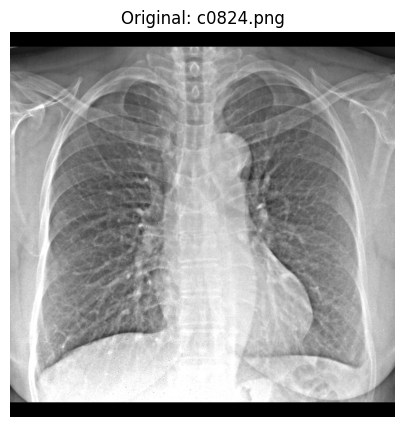

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

# الـ path الصح
DATA_PATH = '/kaggle/input/datasets/hryan007/cxr-lung-dataset-png'

# جمع كل الصور
img_files = [
    os.path.join(DATA_PATH, f)
    for f in os.listdir(DATA_PATH)
    if f.endswith('.png') or f.endswith('.jpg')
]

print(f"✅ عدد الصور: {len(img_files)}")
print(f"📁 مثال: {img_files[0]}")

# تحميل أول صورة
img      = cv2.imread(img_files[0])
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title(f'Original: {os.path.basename(img_files[0])}')
plt.axis('off')
plt.show()

**Preprocessing**

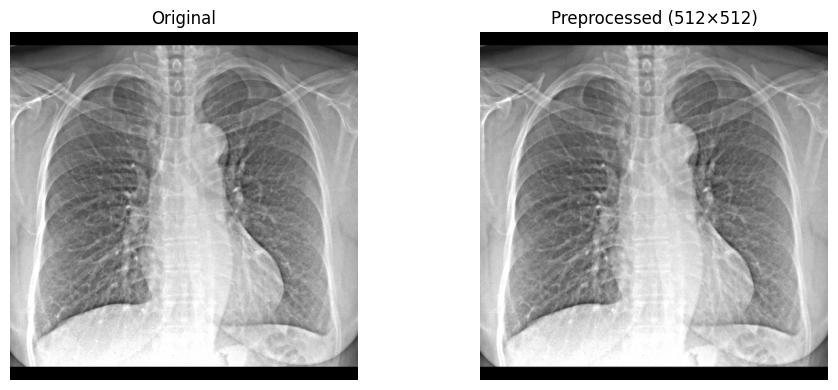

Shape: (512, 512) | Min: 0 | Max: 255


In [8]:
img_resized    = cv2.resize(img_gray, (512, 512))
img_normalized = cv2.normalize(img_resized, None, 0, 255, cv2.NORM_MINMAX)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray,       cmap='gray'); axes[0].set_title('Original');              axes[0].axis('off')
axes[1].imshow(img_normalized, cmap='gray'); axes[1].set_title('Preprocessed (512×512)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Shape: {img_normalized.shape} | Min: {img_normalized.min()} | Max: {img_normalized.max()}")

**Noise Removal**

/tmp/ipykernel_55/134004957.py:9: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


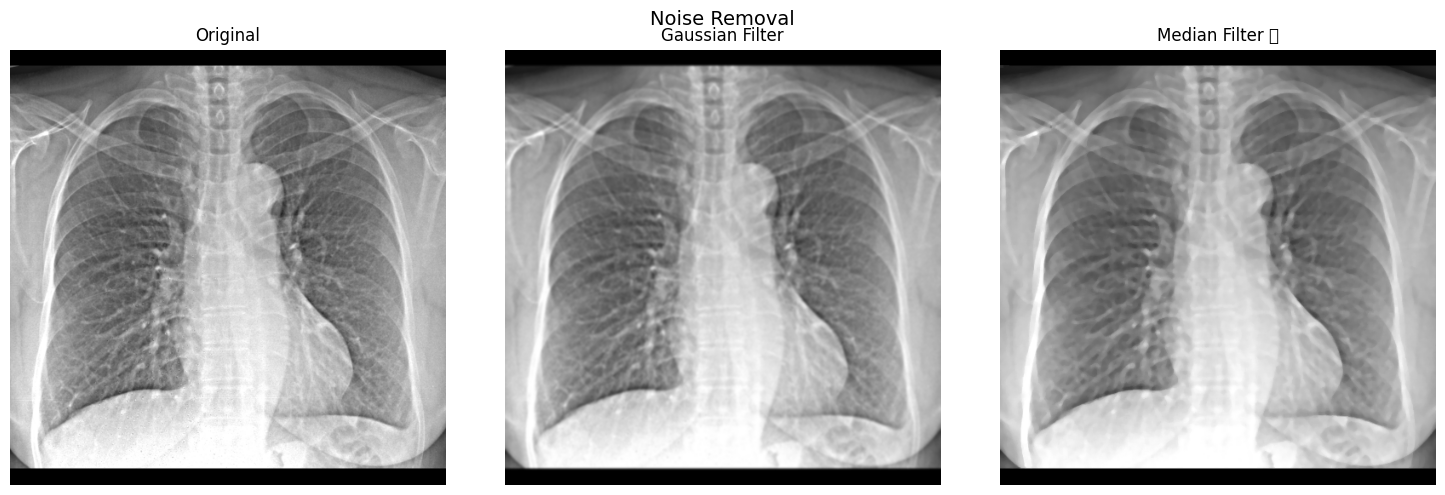

✅ Noise Removal done — img_denoised جاهز


In [9]:
img_gaussian = cv2.GaussianBlur(img_normalized, (5, 5), 0)
img_median   = cv2.medianBlur(img_normalized, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_normalized, cmap='gray'); axes[0].set_title('Original');        axes[0].axis('off')
axes[1].imshow(img_gaussian,   cmap='gray'); axes[1].set_title('Gaussian Filter'); axes[1].axis('off')
axes[2].imshow(img_median,     cmap='gray'); axes[2].set_title('Median Filter ✅'); axes[2].axis('off')
plt.suptitle('Noise Removal', fontsize=14)
plt.tight_layout()
plt.show()

img_denoised = img_median
print("✅ Noise Removal done — img_denoised جاهز")

**Contrast Enhancement**

/tmp/ipykernel_55/2832015928.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1][0].hist(img_denoised.ravel(), 256, [0,256], color='gray');  axes[1][0].set_title('Histogram - Original')
/tmp/ipykernel_55/2832015928.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1][1].hist(img_he.ravel(),       256, [0,256], color='blue');  axes[1][1].set_title('Histogram - HE')
/tmp/ipykernel_55/2832015928.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1][2].hist(img_clahe.ravel(),    256, [0,256], color='green'); axes[1][2].set_title('Histogram - CLAHE')


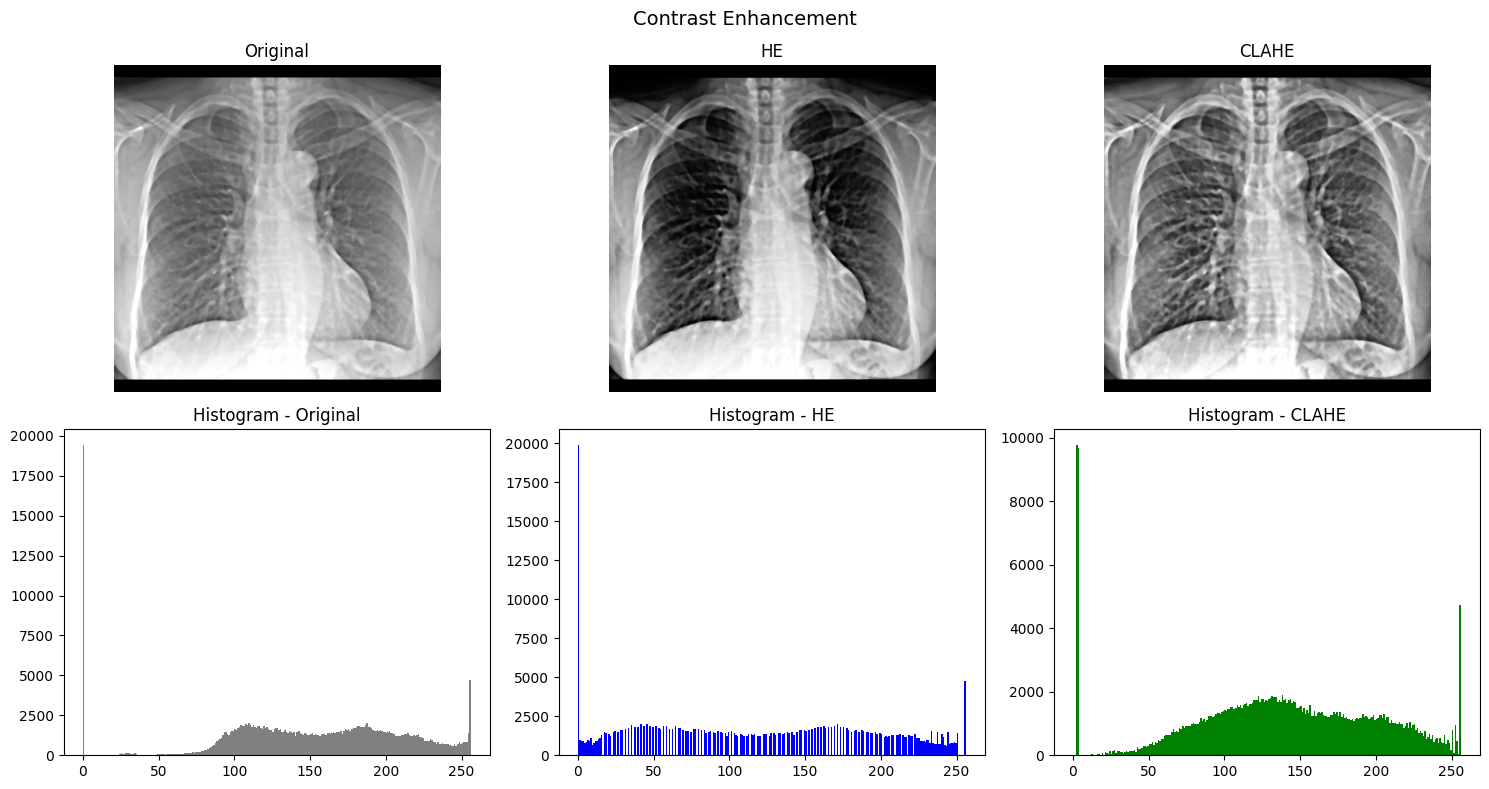

Contrast Enhancement done - img_contrast ready


In [10]:
img_he    = cv2.equalizeHist(img_denoised)
clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_denoised)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# الصور
axes[0][0].imshow(img_denoised, cmap='gray'); axes[0][0].set_title('Original');  axes[0][0].axis('off')
axes[0][1].imshow(img_he,       cmap='gray'); axes[0][1].set_title('HE');        axes[0][1].axis('off')
axes[0][2].imshow(img_clahe,    cmap='gray'); axes[0][2].set_title('CLAHE');     axes[0][2].axis('off')

# الـ Histograms
axes[1][0].hist(img_denoised.ravel(), 256, [0,256], color='gray');  axes[1][0].set_title('Histogram - Original')
axes[1][1].hist(img_he.ravel(),       256, [0,256], color='blue');  axes[1][1].set_title('Histogram - HE')
axes[1][2].hist(img_clahe.ravel(),    256, [0,256], color='green'); axes[1][2].set_title('Histogram - CLAHE')

plt.suptitle('Contrast Enhancement', fontsize=14)
plt.tight_layout()
plt.show()

img_contrast = img_clahe
print("Contrast Enhancement done - img_contrast ready")

**Sharpening**

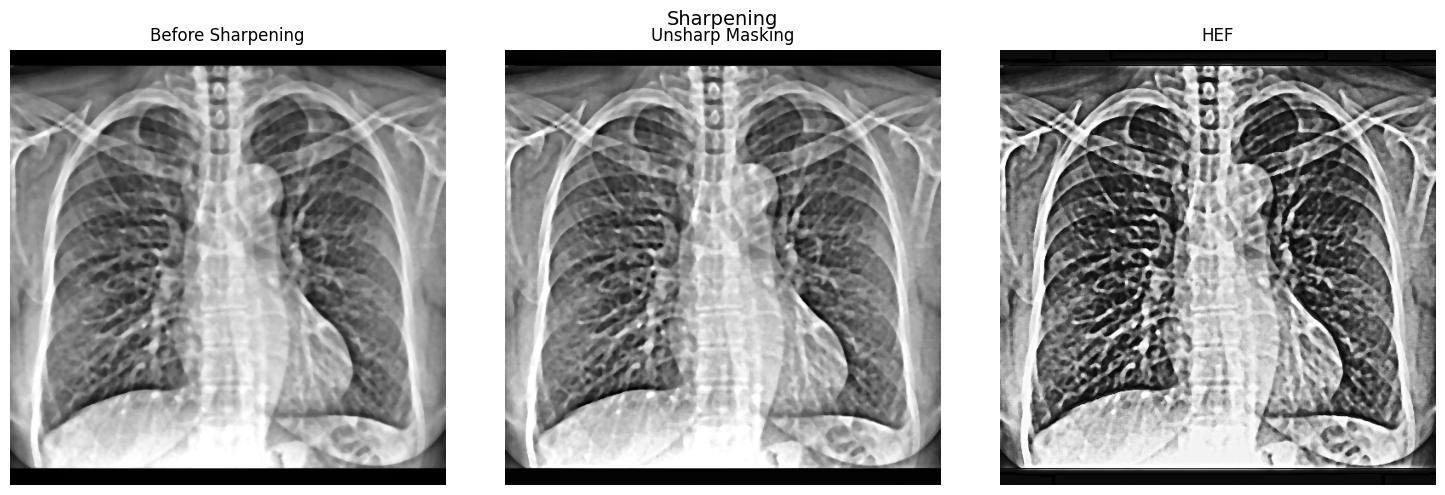

Sharpening done - img_sharpened ready


In [11]:
# Unsharp Masking
img_blur  = cv2.GaussianBlur(img_contrast, (9, 9), 10)
img_sharp = cv2.addWeighted(img_contrast, 1.5, img_blur, -0.5, 0)

# High Frequency Emphasis Filter (HEF)
f          = np.fft.fft2(img_contrast)
fshift     = np.fft.fftshift(f)
rows, cols = img_contrast.shape
crow, ccol = rows // 2, cols // 2
x = np.arange(-ccol, ccol)
y = np.arange(-crow, crow)
X, Y = np.meshgrid(x, y)
D    = np.sqrt(X**2 + Y**2)
H_em = 0.5 + (1 - np.exp(-D**2 / (2 * 30**2)))
img_hef = cv2.normalize(
    np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * H_em))),
    None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)
img_hef = cv2.equalizeHist(img_hef)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_contrast, cmap='gray'); axes[0].set_title('Before Sharpening'); axes[0].axis('off')
axes[1].imshow(img_sharp,    cmap='gray'); axes[1].set_title('Unsharp Masking');   axes[1].axis('off')
axes[2].imshow(img_hef,      cmap='gray'); axes[2].set_title('HEF');               axes[2].axis('off')
plt.suptitle('Sharpening', fontsize=14)
plt.tight_layout()
plt.show()

img_sharpened = img_sharp
print("Sharpening done - img_sharpened ready")

**Morphological Operations**

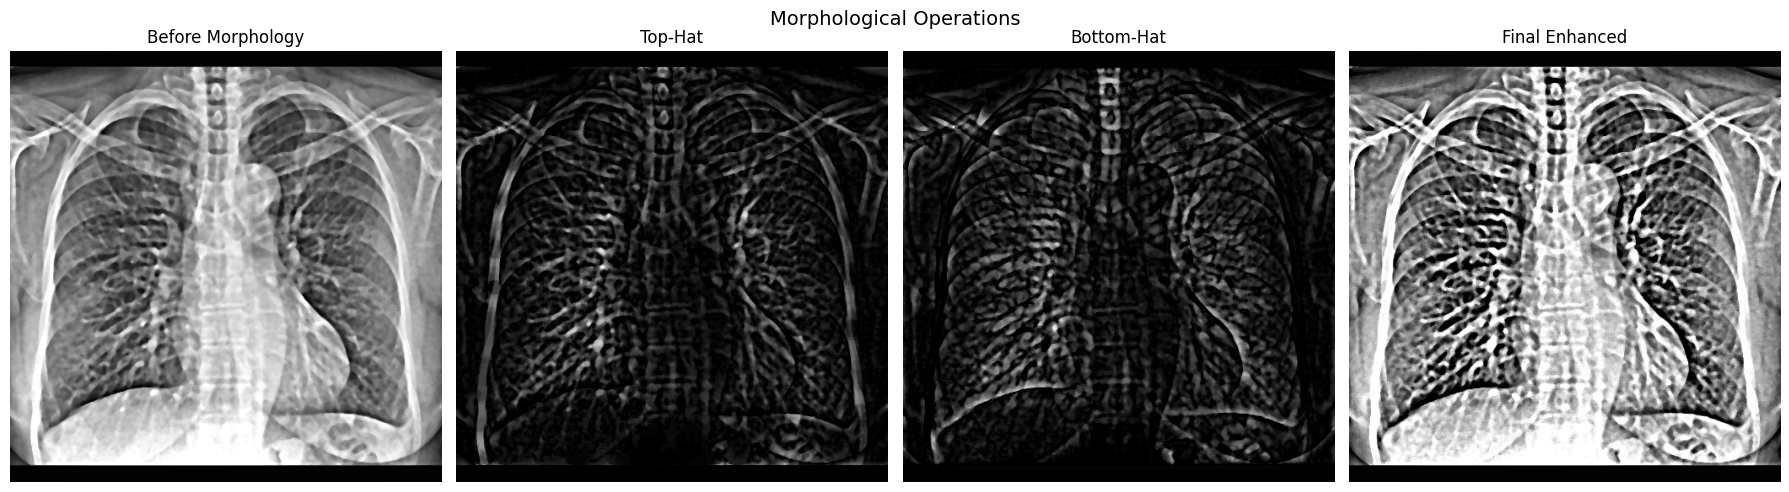

Morphological Operations done - img_final ready


In [12]:
kernel      = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
img_tophat  = cv2.morphologyEx(img_sharpened, cv2.MORPH_TOPHAT,   kernel)
img_bothat  = cv2.morphologyEx(img_sharpened, cv2.MORPH_BLACKHAT, kernel)
img_morphed = cv2.subtract(cv2.add(img_sharpened, img_tophat), img_bothat)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img_sharpened, cmap='gray'); axes[0].set_title('Before Morphology'); axes[0].axis('off')
axes[1].imshow(img_tophat,    cmap='gray'); axes[1].set_title('Top-Hat');           axes[1].axis('off')
axes[2].imshow(img_bothat,    cmap='gray'); axes[2].set_title('Bottom-Hat');        axes[2].axis('off')
axes[3].imshow(img_morphed,   cmap='gray'); axes[3].set_title('Final Enhanced');    axes[3].axis('off')
plt.suptitle('Morphological Operations', fontsize=14)
plt.tight_layout()
plt.show()

img_final = img_morphed
print("Morphological Operations done - img_final ready")

**Evaluation**

         Quality Metrics
  PSNR            : 14.78 dB  (كلما زاد احسن)
  SSIM            : 0.4404    (اقرب لـ 1 احسن)
  Entropy (before): 7.3354
  Entropy (after) : 7.4725  (كلما زاد = تفاصيل اكتر)


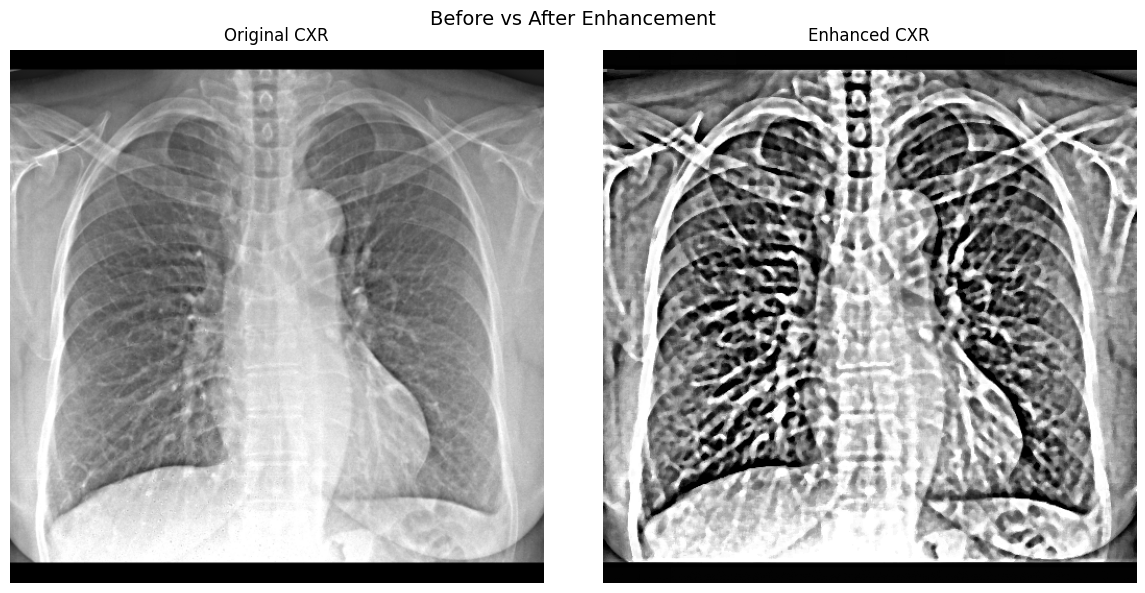

Saved: enhanced_cxr.png


In [13]:
psnr_val = psnr(img_normalized, img_final)
ssim_val = ssim(img_normalized, img_final)

def calc_entropy(img):
    hist, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])
    p = hist / hist.sum()
    return -np.sum(p * np.log2(p + 1e-10))

entropy_before = calc_entropy(img_normalized)
entropy_after  = calc_entropy(img_final)

print("=" * 42)
print("         Quality Metrics")
print("=" * 42)
print(f"  PSNR            : {psnr_val:.2f} dB  (كلما زاد احسن)")
print(f"  SSIM            : {ssim_val:.4f}    (اقرب لـ 1 احسن)")
print(f"  Entropy (before): {entropy_before:.4f}")
print(f"  Entropy (after) : {entropy_after:.4f}  (كلما زاد = تفاصيل اكتر)")
print("=" * 42)

# المقارنة النهائية
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_normalized, cmap='gray'); axes[0].set_title('Original CXR');  axes[0].axis('off')
axes[1].imshow(img_final,      cmap='gray'); axes[1].set_title('Enhanced CXR');  axes[1].axis('off')
plt.suptitle('Before vs After Enhancement', fontsize=14)
plt.tight_layout()
plt.show()

# حفظ الصورة النهائية
cv2.imwrite('enhanced_cxr.png', img_final)
print("Saved: enhanced_cxr.png")